# **DATA UNDERSTANDING PADA DATASET NASA C-MAPSS**

### 1. Business Understanding

Predictive Maintenance berbasis deep learning causal-aware sangat krusial bagi sistem siber-fisik industri, karena mampu memberikan analisis akar masalah yang dapat diinterpretasikan untuk mencegah downtime mesin yang tidak terduga. Model prediktif yang ada saat ini berfokus pada pencarian arsitektur kausal yang paling akurat dan kompleks (misalnya Transformer-GNN) untuk mendeteksi anomali, tanpa mempertimbangkan beban komputasi berat yang dibutuhkan untuk edge computing. Hal ini membuat model state-of-the-art tersebut mustahil diterapkan secara real-time pada skala industri dan mengabaikan keterbatasan perangkat keras dari perangkat IoT di lapangan.

Untuk mengatasi masalah di atas, penelitian ini menyajikan pendekatan causal knowledge distillation baru yang memungkinkan penerapan penalaran kausal yang kompleks pada perangkat edge dengan sumber daya terbatas, dengan mempertimbangkan ketergantungan spasiotemporal dari sensor IoT multivariat. Ide inti di balik metode yang diusulkan adalah untuk memprediksi kerusakan mesin dan mempertahankan interpretabilitas kausal berdasarkan arsitektur "Murid" yang ringan hasil distilasi, alih-alih mengandalkan model "Guru" berkapasitas komputasi berat yang membutuhkan pemrosesan cloud terus-menerus dan bandwidth tinggi.

Sebelum masuk kebagian Data Preparation dan Modeling, dilakukan Data Understanding untuk memahami isi dari data

### 2. Sumber Dataset
* Sumber Data: NASA C-MAPSS
* Data Governance: NASA
* Input: Multi-variate time-series data from 21 sensors (Temperature, Pressure, Fan Speeds, etc.)
* Ukuran: 20631 data, 26 kolom
* Cara Akses: Kaggle


### 3. Tahapan Data Understanding
1. Load Data
2. Describe Data
3. Explore Data

### 4. NASA C-MAPSS

| Item | Detail |
|---|---|
| **Nama Dataset** | NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) — FD001 |
| **Sumber** | NASA Prognostics Center of Excellence (PCoE), Ames Research Center |
| **URL** | https://data.nasa.gov/Aerospace/CMAPSS-Jet-Engine-Simulated-Data/ff5v-kuh6 |
| **Referensi** | Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). *Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation.* PHM08. |
| **Lisensi** | Public Domain (NASA Open Data) |
| **Tujuan Asli** | Prognostics & Health Management — prediksi Remaining Useful Life (RUL) mesin turbin |
| **Metode Pengumpulan** | Simulasi komputer (C-MAPSS simulator) |
| **Temporal Scope** | Simulasi run-to-failure; setiap unit beroperasi dari kondisi normal hingga kegagalan |
| **Jumlah Engine** | 100 unit (training set) |
| **Jumlah Fitur** | 26 kolom (1 unit ID, 1 time cycle, 3 operational settings, 21 sensor measurements) |
| **Ethical Clearance** | Tidak diperlukan — data simulasi, bukan data manusia |
| **Versi** | Accessed March 2026 |
| **Known Limitations** | Data simulasi; tidak mencerminkan noise dunia nyata sepenuhnya. Single fault mode & single operating condition di FD001. |

#### Repurposed Data Assessment
Dataset ini awalnya dirancang untuk kompetisi PHM08 (Prognostics and Health Management). Penggunaannya untuk tugas Data Understanding ini merupakan *repurposed use*, namun tetap valid karena:
1. Variabel yang tersedia sesuai dengan kebutuhan analisis time-series degradation
2. Ground truth RUL tersedia untuk validasi

#### Kolom pada Dataset
1. Unit Number
2. Time Cycles
3. Setting 1 (Operational Settings)
4. Setting 2 (Operational Settings)
5. Setting 3 (Operational Settings)
6. T2 (Temperatures & Pressures)
7. T24 (Temperatures & Pressures)
8. T30 (Temperatures & Pressures)
9. T50 (Temperatures & Pressures)
10. P2 (Temperatures & Pressures)
11. P15 (Temperatures & Pressures)
12. P30 (Temperatures & Pressures)
13. Nf (Rotational Speeds)
14. Nc (Rotational Speeds)
15. epr (Rotational Speeds)
16. Ps30 (Rotational Speeds)
17. phi (Rotational Speeds)
18. NRf (Rotational Speeds)
19. NRc (Rotational Speeds)
20. BPR (Others)
21. farB (Others)
22. htBleed (Others)
23. Nf_dmd (Others)
24. PCNfR_dmd (Others)
25. W31 (Others)
26. W32 (Others)

### 5. Methodology & Approach

#### A. Data Cleaning & Feature Selection
Tidak semua sensor berisi informasi yang penting. Setelah dilakukan Exploratory Data Analysis (EDA), ditemukan ada 7 sensor yang menghasilkan nilai konstan. Oleh karena itu, sensor tersebut dihapus. Sensor-sensor tersebut yaitu 'setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd'


# 1. Load Data


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

train_fd001 = pd.read_csv("/content/train_FD001.txt", sep=" ", header=None)

# 2. Describe Data

In [3]:
train_fd001.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [4]:
train_fd001 = train_fd001.drop(columns=[26,27])

In [5]:
columns = ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
           'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
           'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
           'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']

train_fd001.columns = columns

In [6]:
train_fd001.shape

(20631, 26)

In [7]:
train_fd001.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

In [8]:
train_fd001.duplicated().sum()

np.int64(0)

In [9]:
train_fd001.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


In [10]:
train_fd001.skew()

,0
unit_number,-0.067815
time_cycles,0.499904
setting_1,-0.024766
setting_2,0.009085
setting_3,0.000000
T2,0.000000
T24,0.316526
T30,0.308946
T50,0.443194
P2,0.000000


In [11]:
train_fd001.kurtosis()

,0
unit_number,-1.219824
time_cycles,-0.218539
setting_1,-0.009132
setting_2,-1.130447
setting_3,0.000000
T2,0.000000
T24,-0.112043
T30,0.007762
T50,-0.163681
P2,0.000000


In [12]:
train_fd001.corr()

,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
unit_number,1.000000,0.078753,-0.017895,-0.006197,NaN,NaN,0.014133,0.012621,0.026116,NaN,...,-0.031882,0.044230,-0.059473,0.022486,NaN,0.013513,NaN,NaN,-0.020589,-0.016465
time_cycles,0.078753,1.000000,-0.004527,0.016132,NaN,NaN,0.549898,0.543947,0.624577,NaN,...,-0.611354,0.477523,0.370324,0.588676,NaN,0.566995,NaN,NaN,-0.583597,-0.585923
setting_1,-0.017895,-0.004527,1.000000,0.011660,NaN,NaN,0.009030,-0.005651,0.009544,NaN,...,-0.001491,0.002318,-0.004469,0.007652,NaN,0.002599,NaN,NaN,-0.005713,-0.014559
setting_2,-0.006197,0.016132,0.011660,1.000000,NaN,NaN,0.007266,0.009068,0.014673,NaN,...,-0.010923,0.018156,-0.006310,0.014156,NaN,0.012280,NaN,NaN,-0.010554,-0.007846
setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
T2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
T24,0.014133,0.549898,0.009030,0.007266,NaN,NaN,1.000000,0.602610,0.714949,NaN,...,-0.724578,0.661792,0.179752,0.675975,NaN,0.629886,NaN,NaN,-0.661841,-0.668050
T30,0.012621,0.543947,-0.005651,0.009068,NaN,NaN,0.602610,1.000000,0.678413,NaN,...,-0.680307,0.600963,0.237137,0.639921,NaN,0.600017,NaN,NaN,-0.625941,-0.633901
T50,0.026116,0.624577,0.009544,0.014673,NaN,NaN,0.714949,0.678413,1.000000,NaN,...,-0.815591,0.745158,0.190748,0.758459,NaN,0.703499,NaN,NaN,-0.748067,-0.745193
P2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
constant_features = [col for col in train_fd001.columns if train_fd001[col].nunique() <= 1]

print(f'Dead/Constant Sensors: {constant_features}')
print(f'Jumlah Dead Sensors: {len(constant_features)} sensors.')

Dead/Constant Sensors: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Jumlah Dead Sensors: 7 sensors.


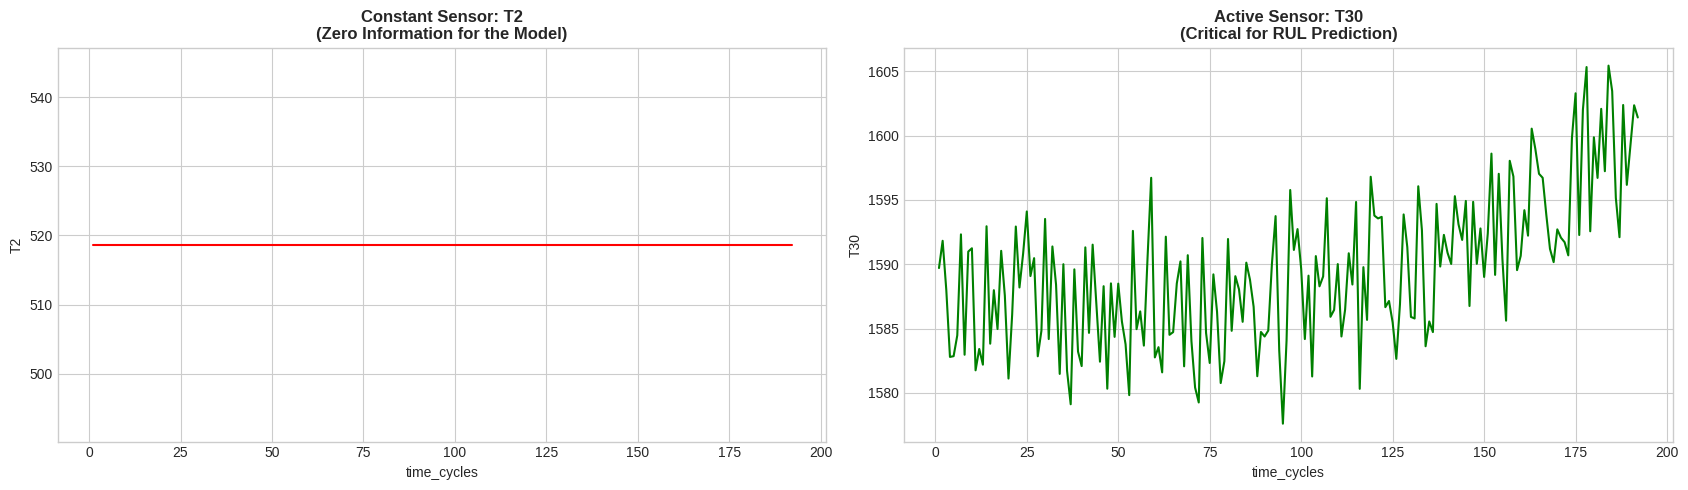

In [14]:
dead_sensor = 'T2'
active_sensor = 'T30'

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

# Plot Dead Sensor
sns.lineplot(x='time_cycles', y=dead_sensor,
             data=train_fd001[train_fd001['unit_number'] == 1],
             ax=ax[0], color='r')
ax[0].set_title(
    f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
    fontweight='bold')

# Plot Active Sensor
sns.lineplot(x='time_cycles', y=active_sensor,
             data=train_fd001[train_fd001['unit_number'] == 1],
             ax=ax[1], color='g')
ax[1].set_title( f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)',
                 fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Drop dead sensor
train_fd001.drop(columns=constant_features, inplace=True)

print("\nDropped constant columns successfully.")
print(f"New Training Shape: {train_fd001.shape}")


Dropped constant columns successfully.
New Training Shape: (20631, 19)


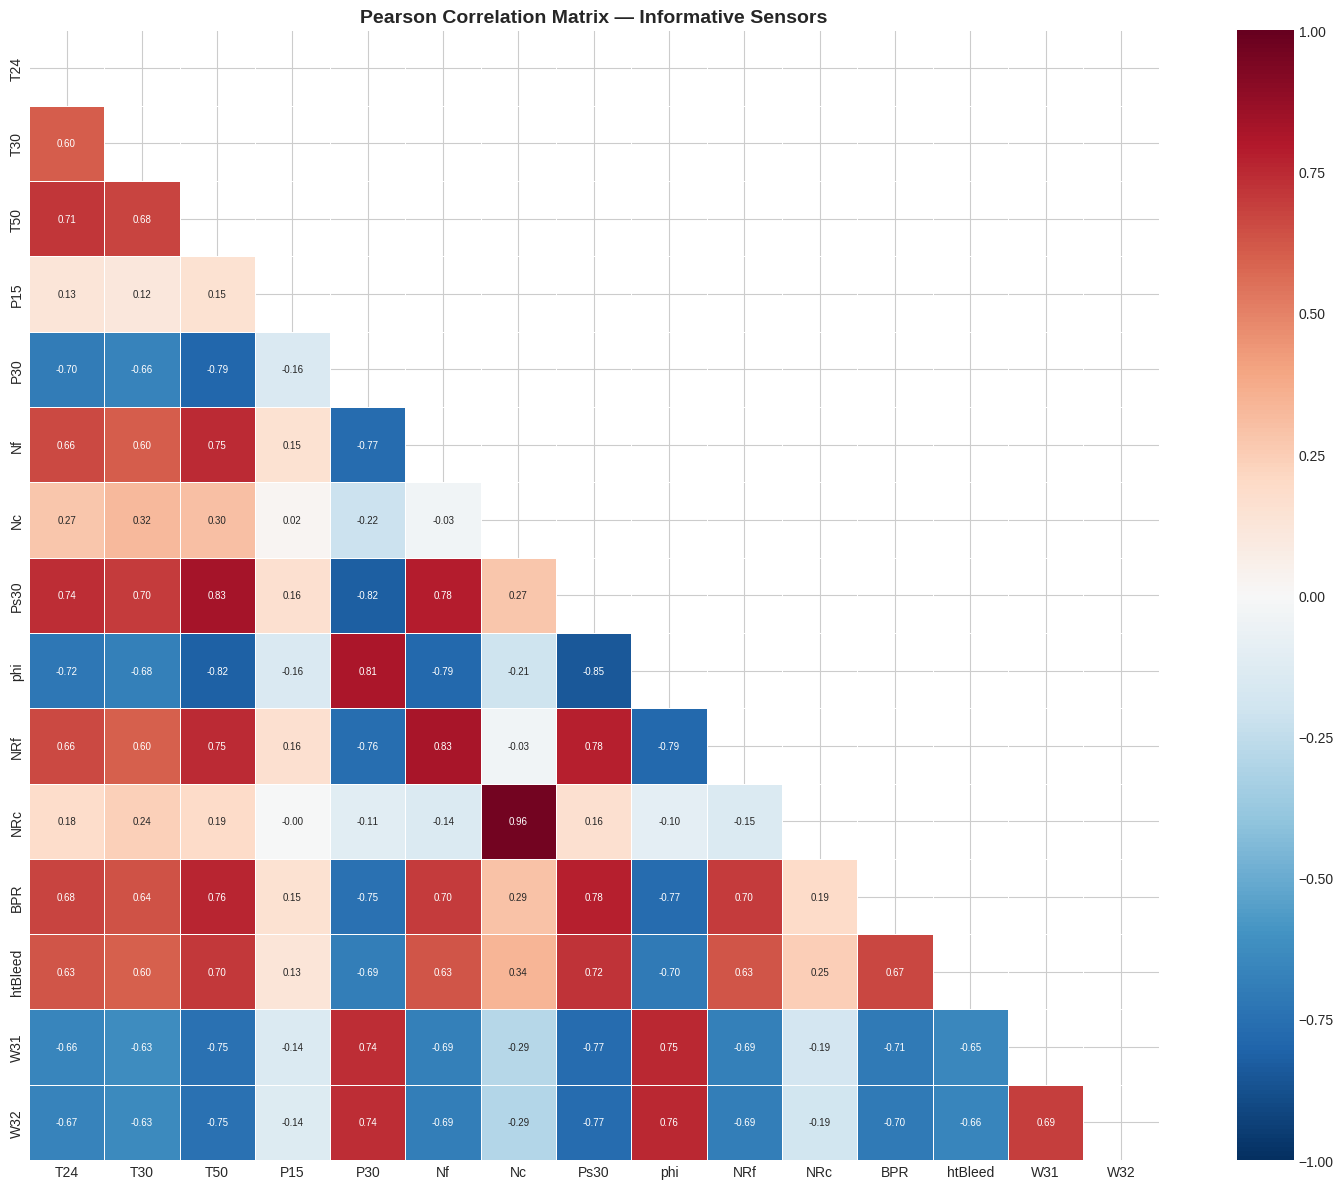


Highly Correlated Pairs (|r| > 0.8):
  Nc ↔ NRc: r = 0.963
  Ps30 ↔ phi: r = -0.847
  T50 ↔ Ps30: r = 0.830
  Nf ↔ NRf: r = 0.826
  P30 ↔ Ps30: r = -0.823
  T50 ↔ phi: r = -0.816
  P30 ↔ phi: r = 0.813


In [16]:
# Pearson Correlation Heatmap
corr = train_fd001.drop(columns=['unit_number', 'time_cycles', 'setting_1', 'setting_2']).corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix — Informative Sensors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifikasi highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("\nHighly Correlated Pairs (|r| > 0.8):")
for s1, s2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {s1} ↔ {s2}: r = {r:.3f}")

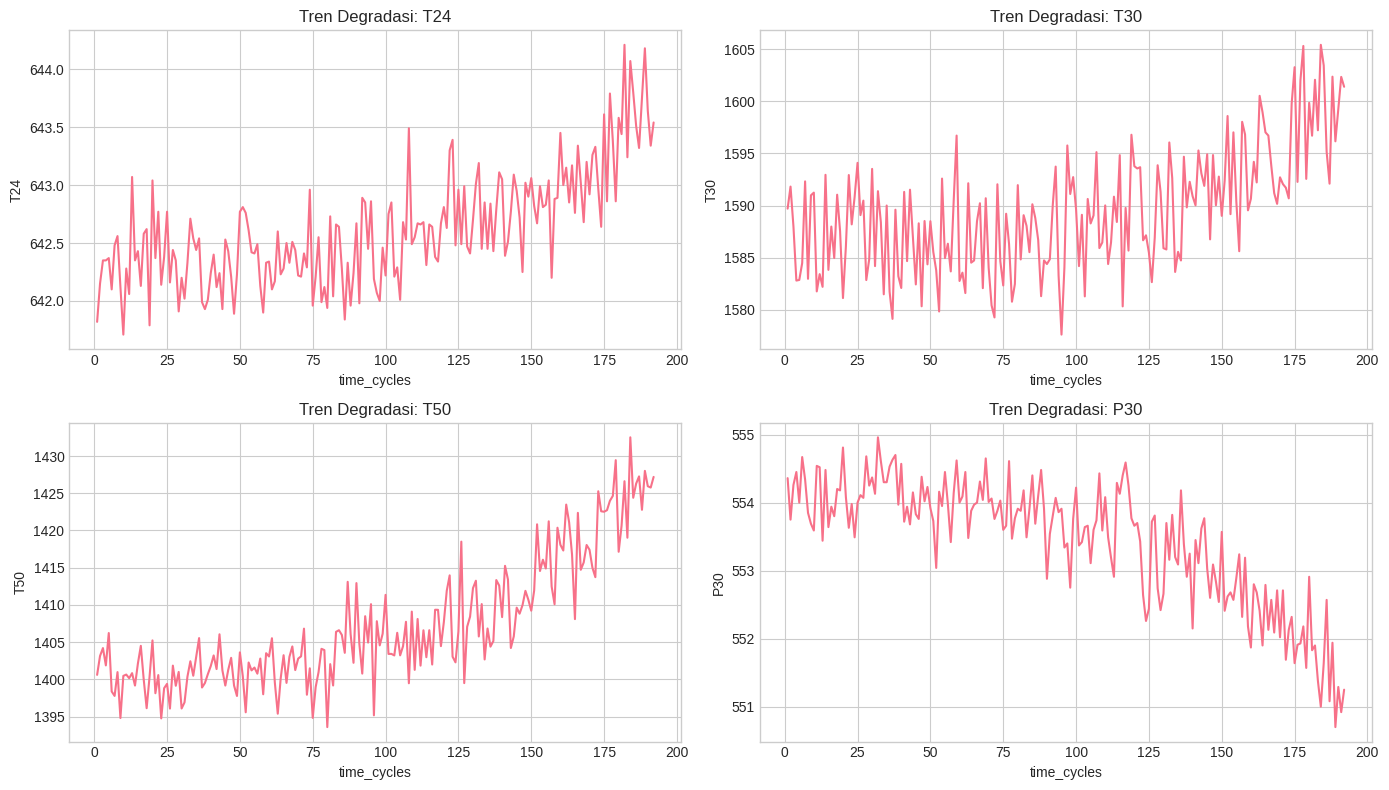

In [17]:
# Visualisasi Tren Degradasi (Sensor terpilih pada satu mesin)
# Memilih mesin pertama (unit_number = 1) untuk melihat pergeseran distribusi
engine_1 = train_fd001[train_fd001['unit_number'] == 1]
sensors_to_plot = ['T24', 'T30', 'T50', 'P30']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, sensor in zip(axes.flatten(), sensors_to_plot):
    sns.lineplot(data=engine_1, x='time_cycles', y=sensor, ax=ax)
    ax.set_title(f'Tren Degradasi: {sensor}')
plt.tight_layout()
plt.show()

In [18]:
# Menghitung siklus maksimum per mesin (kapan mesin tersebut rusak)
max_cycles = train_fd001.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

# Merge kembali ke data training
train_fd001 = train_fd001.merge(max_cycles, on='unit_number', how='left')

# Kalkulasi Remaining Useful Life (RUL)
train_fd001['RUL'] = train_fd001['max_cycle'] - train_fd001['time_cycles']

# Terapkan Piecewise Linear Degradation (Clipping RUL di 125)
MAX_RUL = 125
train_fd001['RUL_clipped'] = train_fd001['RUL'].clip(upper=MAX_RUL)

train_fd001.drop(columns=['max_cycle'], inplace=True)

train_fd001[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


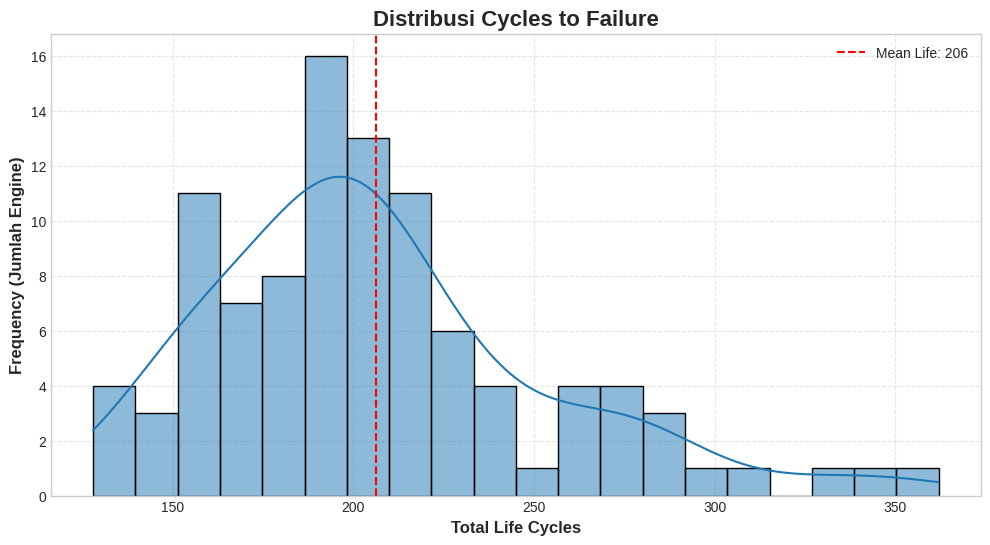

In [19]:
engine_lifespan = train_fd001.groupby('unit_number')['time_cycles'].max()
plt.figure(figsize=(12, 6))
sns.histplot(engine_lifespan, kde=True, color='#1f77b4', bins=20)
plt.title('Distribusi Cycles to Failure', fontweight='bold', size=16)
plt.xlabel('Total Life Cycles', fontweight='bold', size=12)
plt.ylabel('Frequency (Jumlah Engine)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}')
plt.legend()
plt.show()

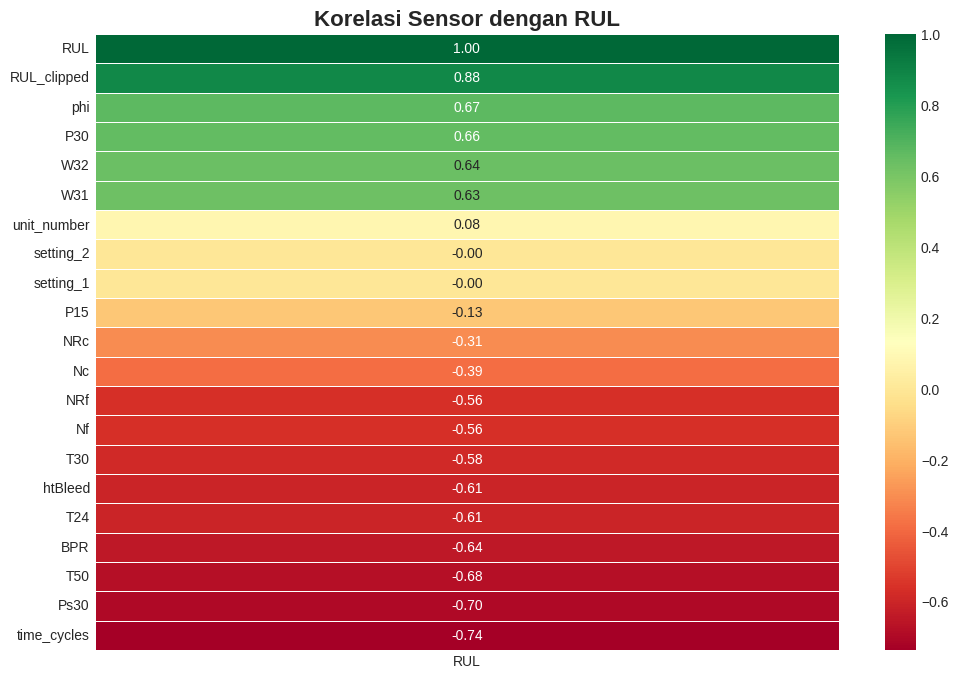

Insight: Sensor dengan korelasi positif atau negatif yang tinggi merupakan prediktor yang paling penting.


In [20]:
# Correlation Heatmap

# Which sensors correlate most strongly with RUL?
corr_matrix = train_fd001.corr()
rul_corr = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(12, 8))
sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Sensor dengan RUL', fontsize=16, fontweight='bold')
plt.show()

print("Insight: Sensor dengan korelasi positif atau negatif yang tinggi merupakan prediktor yang paling penting.")

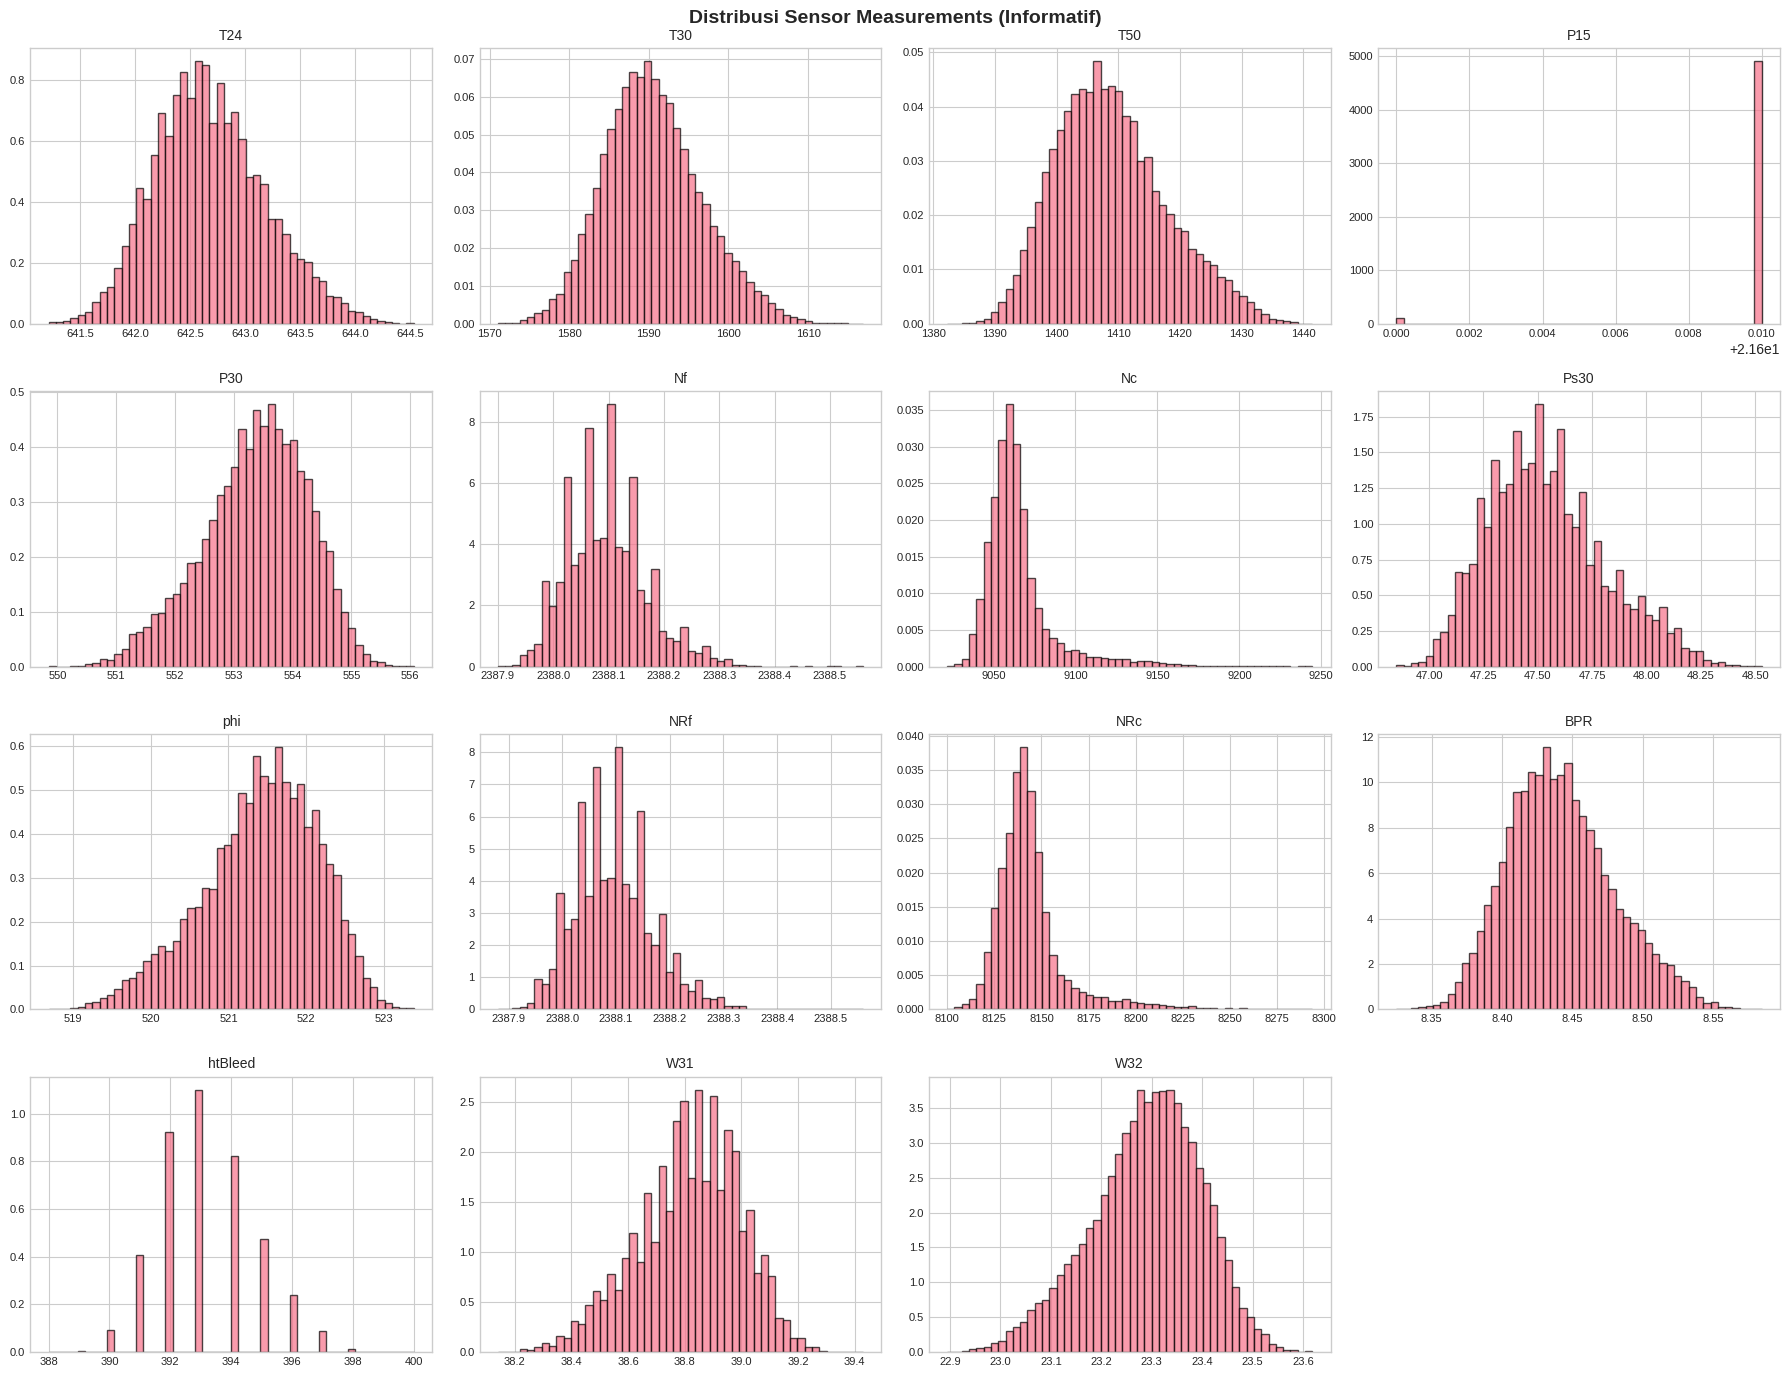

In [21]:
# Visualisasi distribusi sensor yang informatif (exclude constant sensors)
pengecualian = ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'RUL', 'RUL_clipped']
informative_sensors = [s for s in train_fd001 if s not in pengecualian]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(informative_sensors[:16]):
    axes[i].hist(train_fd001[col], bins=50, alpha=0.7, edgecolor='black', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Sensor Measurements (Informatif)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
train_fd001.head()

,unit_number,time_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,...,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187,125
